In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
os.environ["KERAS_BACKEND"] = "torch"

In [33]:
# Leggi i file jpg dentro la cartella Pistachio_Image_Dataset
# Crea array X (immagini) e y (etichette) e salva in formato .npy
from pathlib import Path
from PIL import Image

base_dir = Path('../dataset_big/Pistachio_Image_Dataset/Pistachio_Image_Dataset')
class_dirs = [d for d in base_dir.iterdir() if d.is_dir()]
class_dirs = sorted(class_dirs)
images = []
labels = []
for label_idx, class_dir in enumerate(class_dirs):
    for img_path in class_dir.glob('*.jpg'):
        try:
            img = Image.open(img_path).convert('RGB')
            arr = np.array(img)
            images.append(arr)
            labels.append(label_idx)
        except Exception as e:
            print(f'Errore su {img_path}: {e}')

X = np.stack(images)
y = np.array(labels, dtype=np.int64)

class_mapping = {i: d.name for i, d in enumerate(class_dirs)}
print('Classi trovate:', class_mapping)
print('Shape X:', X.shape, 'Shape y:', y.shape)

Classi trovate: {0: 'Kirmizi_Pistachio', 1: 'Siirt_Pistachio'}
Shape X: (2148, 600, 600, 3) Shape y: (2148,)


In [34]:
# Riscala tutte le immagini a 50x50 senza tagliare (nearest neighbor) usando solo numpy
def resize_to_50(img):
    h, w = img.shape[:2]
    y_idx = np.linspace(0, h - 1, 50).round().astype(int)
    x_idx = np.linspace(0, w - 1, 50).round().astype(int)
    return img[y_idx][:, x_idx]

X50 = np.stack([resize_to_50(im) for im in X])
print('Original shape:', X.shape, 'Rescaled shape:', X50.shape)


Original shape: (2148, 600, 600, 3) Rescaled shape: (2148, 50, 50, 3)


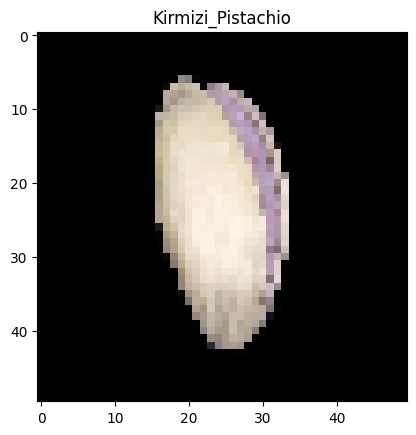

In [35]:
# usa plt.imshow per visualizzare la prima immagine.
# metti la label corretta come titolo.
id = 5
plt.imshow(X50[id])
plt.title(class_mapping[y[id]])
plt.show()

In [36]:
# fai il train test split 80 20

X50 = X50.astype("float32") / 255

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X50, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', x_train.shape, 'Test shape:', x_test.shape)

Train shape: (1718, 50, 50, 3) Test shape: (430, 50, 50, 3)


In [37]:
num_classes = 2
input_shape = (50, 50, 3)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 19, 19, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,418 (1017.26 KB)

 Trainable params: 260,418 (1017.26 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:

print(x_train.shape)
print(y_train.shape)

(1718, 50, 50, 3)
(1718,)


In [39]:

callbacks = [
    #keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5),
]
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(x_train, y_train, epochs=20, validation_split=0.2, callbacks=callbacks)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.6870 - val_loss: 0.6910
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.6870 - val_loss: 0.6910
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.6770 - val_loss: 0.6743
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.6770 - val_loss: 0.6743
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.6422 - val_loss: 0.5769
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.6422 - val_loss: 0.5769
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.6082 - val_loss: 0.5731
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.6082 - val_loss: 0.5731
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.5734 - val_loss: 0.5073
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.5734 - val_loss: 0.5073
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.5201 - val_loss: 0.4776
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.5201

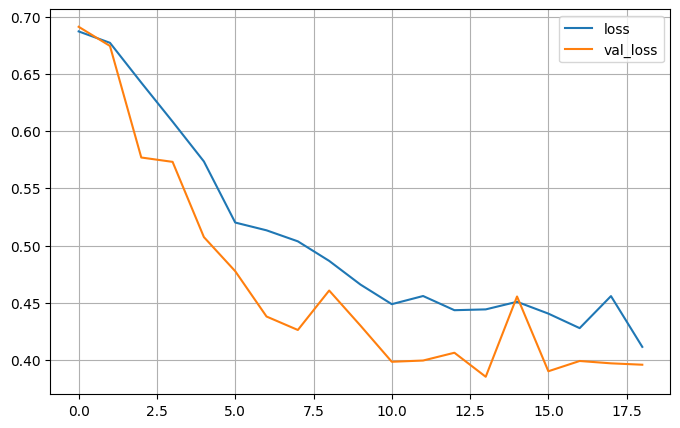

In [40]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [42]:
# predict all test images

predictions = model.predict(x_test)
cpredictions = [np.argmax(p) for p in predictions]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


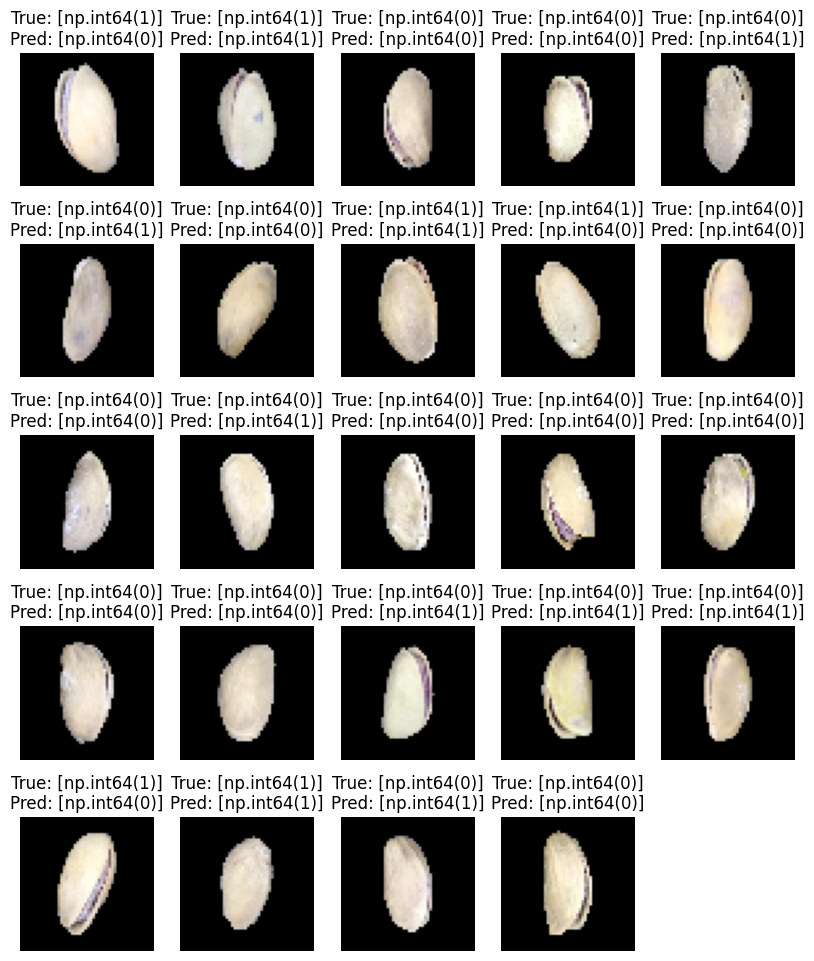

In [44]:
#create a grid of 5 X 5 images with predictions and true labels
plt.figure(figsize=(10,12))
for i in range(1,25):
    img = x_test[-i]
    #img = img.reshape(3, 32, 32).transpose(1, 2, 0)
    plt.subplot(5,5,i)
    plt.title(f'True: {[y_test[-i]]}\nPred: {[cpredictions[i]]}')
    plt.imshow(img)
    plt.axis('off')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


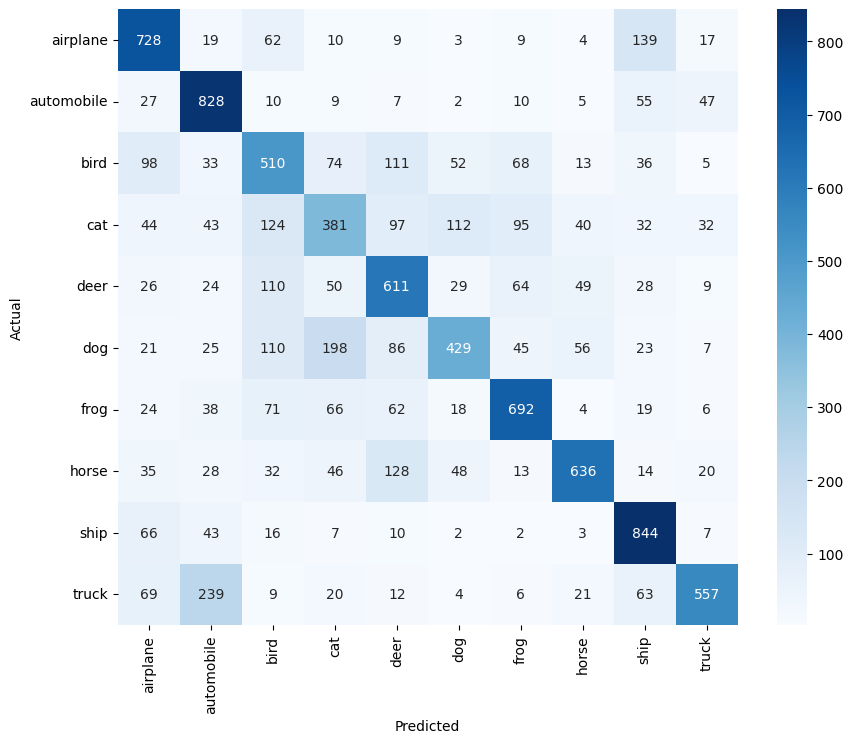

In [75]:
# print confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, cpredictions)
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()